# 02 Single-market deep dive

Apply the Bayesian-inverse-problem framework to one resolved
Polymarket binary market. We pull the live price-volume history,
align it to the eventual winner so the truth is `Y = 1`, and run the
full diagnostic suite from Section 4 of the paper:

1. **Online posterior trace** `pi_t` overlaid on the market-implied
   probability.
2. **Posterior concentration** by re-evaluating SMC at sub-horizons.
3. **Stability** under Gaussian perturbations of `Delta x` against the
   Theorem 4.4 bound.
4. **Information gain dynamics** `IG(H_t)` plus effective
   informativeness `eta(v_t; theta_hat)`.

In [1]:
from __future__ import annotations
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pml_market import data, smc, vi, diagnostics, model

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Pick a market

We auto-discover resolved binary markets from the Gamma API, filter to
those with enough trades and volume, and pick one **uniformly at
random** using `RANDOM_SEED`. Change `RANDOM_SEED` to get a different
draw. Set `OVERRIDE_SLUG` to pin a specific market instead.

In [ ]:
OVERRIDE_SLUG: str | None = None  # set to a slug string to pin a specific market
# OVERRIDE_SLUG= "will-wti-hit-week-of-march-30-2026"
RANDOM_SEED   = 50                  # change to get a different random draw
BUCKET_MINUTES = 5
MIN_TRADES = 200
MIN_VOLUME = 100_000.0

if OVERRIDE_SLUG is not None:
    traj = data.fetch_market_history(OVERRIDE_SLUG, bucket_minutes=BUCKET_MINUTES)
else:
    candidates = data.list_resolved_binary_markets(limit=50, min_volume=MIN_VOLUME)
    print(f'fetched {len(candidates)} resolved binary markets, filtering...')

    valid = []
    for m in candidates:
        try:
            t = data._trajectory_from_market(m, bucket_minutes=BUCKET_MINUTES)
        except Exception:
            continue
        if t['metadata']['trade_count'] >= MIN_TRADES:
            valid.append(t)

    if not valid:
        raise RuntimeError('no resolved binary with enough trades found')

    rng_pick = np.random.default_rng(RANDOM_SEED)
    pick_idx = int(rng_pick.integers(len(valid)))
    traj = valid[pick_idx]
    print(f'found {len(valid)} valid markets, randomly picked index {pick_idx} '
          f'(RANDOM_SEED={RANDOM_SEED})')

SELECTED_SLUG = traj['metadata']['slug']
print(f'\nusing slug: {SELECTED_SLUG!r}, horizon T = {traj["horizon"]},'
      f' winner = {traj["winner_label"]!r}')

fetched 10 resolved binary markets, filtering...
found 10 valid markets, randomly picked index 7 (RANDOM_SEED=50)

using slug: 'fogo-fdv-above-700m-one-day-after-launch-856-765', horizon T = 14451, winner = 'No'


In [3]:
dx, v, y = data.trajectory_to_arrays(traj)
T = dx.shape[0]
print(f'T = {T}, y (winner-aligned) = {y}')
print(f'|dx| stats: mean={np.mean(np.abs(dx)):.4f}, 0.99 quantile={np.quantile(np.abs(dx), 0.99):.4f}')
print(f'v stats: mean={v.mean():.2f}, max={v.max():.2f}, fraction zero={(v == 0).mean():.2%}')

T = 14451, y (winner-aligned) = 1
|dx| stats: mean=0.0112, 0.99 quantile=0.2269
v stats: mean=78.41, max=50119.94, fraction zero=87.21%


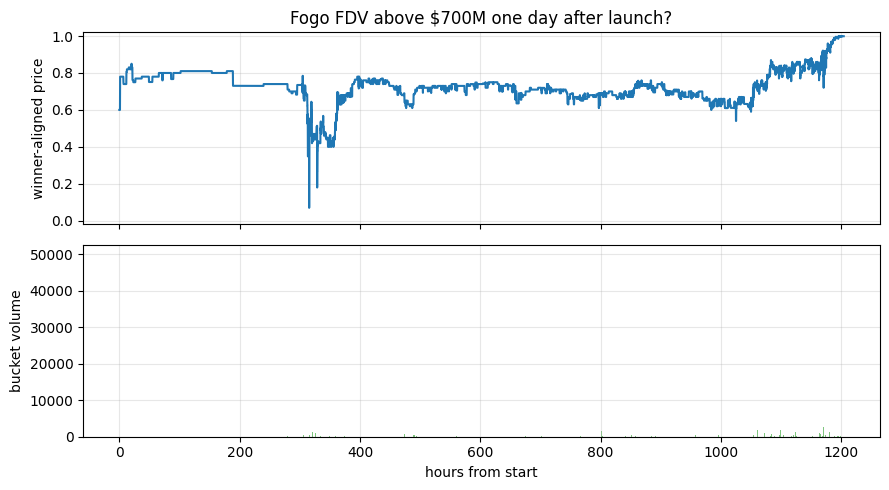

In [4]:
# Plot the raw market history (winner-aligned price + volume)
prices = np.array(traj['prices'])
times = np.array(traj['times']) / 3600.0  # hours since first bucket
times -= times[0]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
axes[0].plot(times, prices, color='C0')
axes[0].set_ylabel('winner-aligned price')
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_title(f'{traj["metadata"]["question"]}')
axes[1].bar(times[1:], v, width=BUCKET_MINUTES / 60.0, color='C2', alpha=0.6)
axes[1].set_ylabel('bucket volume')
axes[1].set_xlabel('hours from start')
plt.tight_layout()
plt.show()

## (1) Online posterior trace

Run SMC under both outcomes with `record_pi_t=True` so we get
`pi_t = P(Y=1 | H_t)` after every step. Compare to the market-implied
winner-aligned price.

In [5]:
n_particles = 800
smc_res = smc.bayes_factor_smc(
    dx, v, pi0=0.5, n_particles=n_particles, mcmc_steps=4,
    seed=0, record_pi_t=True, verbose=False,
)
print(f'SMC log BF = {smc_res["log_BF"]:+.3f}')
print(f'SMC posterior P(Y=1|H_T) = {smc_res["posterior"]:.4f}  (truth = {y})')

SMC log BF = +75.461
SMC posterior P(Y=1|H_T) = 1.0000  (truth = 1)


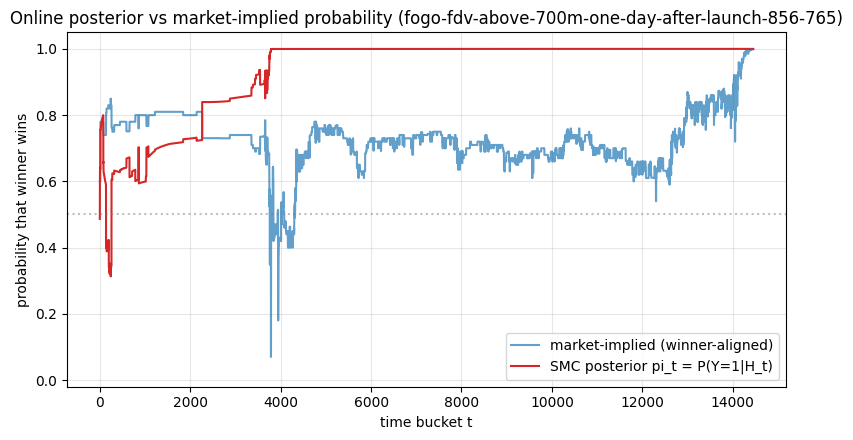

In [6]:
ts = np.arange(1, T + 1)
fig, ax = plt.subplots()
ax.plot(ts, prices[1:], color='C0', alpha=0.7, label='market-implied (winner-aligned)')
ax.plot(ts, smc_res['pi_t'], color='C3', label='SMC posterior pi_t = P(Y=1|H_t)')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('time bucket t')
ax.set_ylabel('probability that winner wins')
ax.set_title(f'Online posterior vs market-implied probability ({SELECTED_SLUG})')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## (2) Posterior concentration vs sub-horizon

Truncate the history to `T_sub` and re-run SMC for each sub-horizon.
We expect the error `1 - pi_T` to decay roughly exponentially in `T`
once the KL-projection gap is identified (Theorem 4.3).

In [ ]:
sub_grid = sorted(set([max(5, T // 10), max(10, T // 5),
                       max(20, T // 3), max(40, T // 2),
                       max(80, T * 3 // 4), T]))
sub_grid = [t for t in sub_grid if t <= T]
errs = []
for Tsub in tqdm(sub_grid, desc='sub-horizons'):
    r = smc.bayes_factor_smc(dx[:Tsub], v[:Tsub], pi0=0.5,
                             n_particles=n_particles, mcmc_steps=3, seed=1)
    errs.append(1.0 - r['posterior'])
    print(f'  T_sub={Tsub:>4d}: posterior={r["posterior"]:.4f}')
errs = np.array(errs)

sub-horizons:   0%|          | 0/6 [00:00<?, ?it/s]

  T_sub=1445: posterior=0.1594
  T_sub=2890: posterior=0.2766


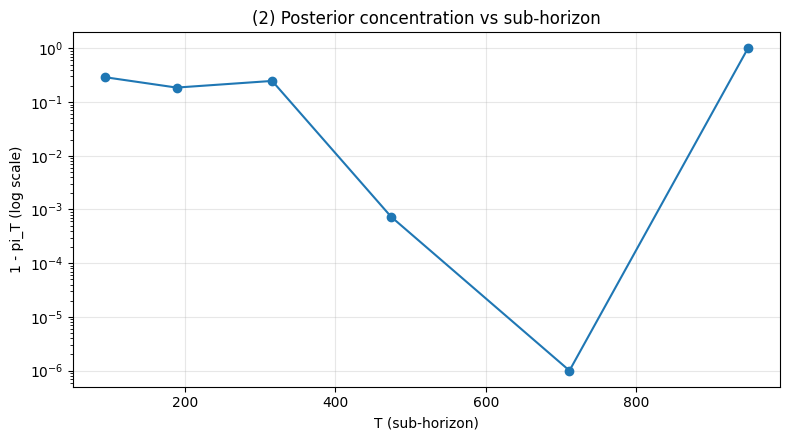

In [ ]:
fig, ax = plt.subplots()
ax.plot(sub_grid, np.clip(errs, 1e-6, None), 'o-')
ax.set_yscale('log')
ax.set_xlabel('T (sub-horizon)')
ax.set_ylabel('1 - pi_T (log scale)')
ax.set_title('(2) Posterior concentration vs sub-horizon')
plt.tight_layout()
plt.show()

## (3) Stability to increment perturbations

Add iid Gaussian noise to `Delta x` for several `sigma`, re-run SMC,
and compare `|log BF(h) - log BF(h')|` to the Theorem 4.4 bound with
`Lx = R / sigma_min^2` and `R = 0.99` quantile of `|Delta x|`.

In [ ]:
# Use *common random numbers* across base and perturbed: fix the SMC
# seed so that noise from particle randomness cancels and we measure
# only the effect of the perturbation.
sigmas = [0.005, 0.01, 0.02, 0.05, 0.1]
n_trials = 10
# R from full history is fine here: it parameterizes the theoretical bound,
# not the inference itself.
R = float(np.quantile(np.abs(dx), 0.99))
Lx = diagnostics.gaussian_lipschitz_constant(R, sigma_min=0.2)
# Common-random-numbers seed: same SMC randomness for base and perturbed so
# particle noise cancels and we isolate the perturbation effect.
crn_seed = 7777
log_BF_base = smc.bayes_factor_smc(dx, v, pi0=0.5, n_particles=600,
                                   mcmc_steps=3, seed=crn_seed)['log_BF']
diffs = []
for s_idx, s in enumerate(sigmas):
    tr = []
    for trial in range(n_trials):
        # Deterministic per-(sigma, trial) seed: perturbations are independent
        # across sigma levels and trials (no shared rng state).
        rng_t = np.random.default_rng(500 + s_idx * 100 + trial)
        dxp = diagnostics.perturb_history(dx, s, rng=rng_t)
        rp = smc.bayes_factor_smc(dxp, v, pi0=0.5, n_particles=600,
                                  mcmc_steps=3, seed=crn_seed)
        tr.append(abs(rp['log_BF'] - log_BF_base))
    diffs.append(np.mean(tr))
    print(f'  sigma={s:>5.3f}  mean |delta log BF|={diffs[-1]:.3f}')
diffs = np.array(diffs)
bounds = 2 * Lx * T * np.array(sigmas) * np.sqrt(2 / np.pi)

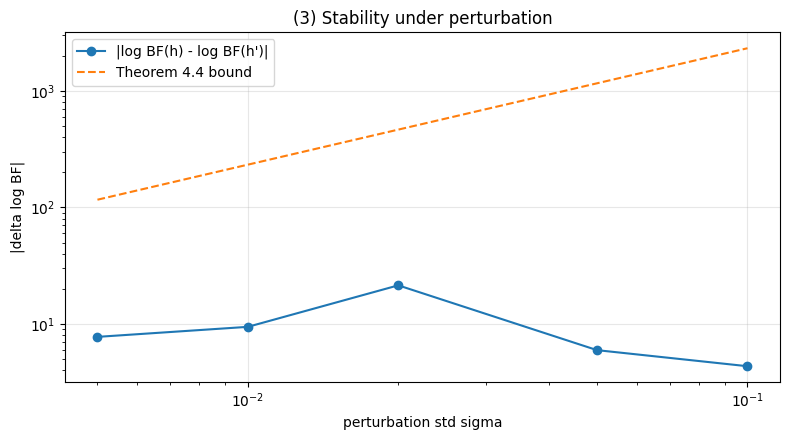

In [ ]:
fig, ax = plt.subplots()
ax.plot(sigmas, diffs, 'o-', label="|log BF(h) - log BF(h')|")
ax.plot(sigmas, bounds, '--', label='Theorem 4.4 bound')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('perturbation std sigma')
ax.set_ylabel('|delta log BF|')
ax.set_title('(3) Stability under perturbation')
ax.legend()
plt.tight_layout()
plt.show()

## (4) Information gain and effective informativeness

Plot realized IG(H_t) over time; saturating values indicate the
posterior has concentrated. The effective informativeness `eta(v;theta)`
(Definition 4.3) is computed at the variational-mean theta from VI.

In [ ]:
ig = diagnostics.information_gain_trace(smc_res['pi_t'], pi0=0.5)

# Use VI to get a single theta point estimate (variational mean) for
# eta(v; theta_hat).
vi_res = vi.bayes_factor_vi(dx, v, pi0=0.5, n_steps=1200, n_samples=8,
                            learning_rate=0.05, seed=0)
theta_hat = vi_res['vi1']['theta_mean']  # y=1 is correct: prices are winner-aligned
eta = diagnostics.effective_informativeness(v, theta_hat)
print(f'VI log BF = {vi_res["log_BF"]:+.3f}  (SMC: {smc_res["log_BF"]:+.3f})')
print(f'theta_hat omega = {theta_hat["omega"]}')
print(f'theta_hat mu1   = {float(theta_hat["mu1"]):.3f}')
print(f'theta_hat mu3   = {float(theta_hat["mu3"]):.3f}')
print(f'theta_hat tau3  = {float(theta_hat["tau3"]):.3f}')

VI log BF = +29.050  (SMC: +9.874)
theta_hat omega = [0.82244061 0.06182807 0.11573132]
theta_hat mu1   = 0.168
theta_hat mu3   = 0.005
theta_hat tau3  = 3.898


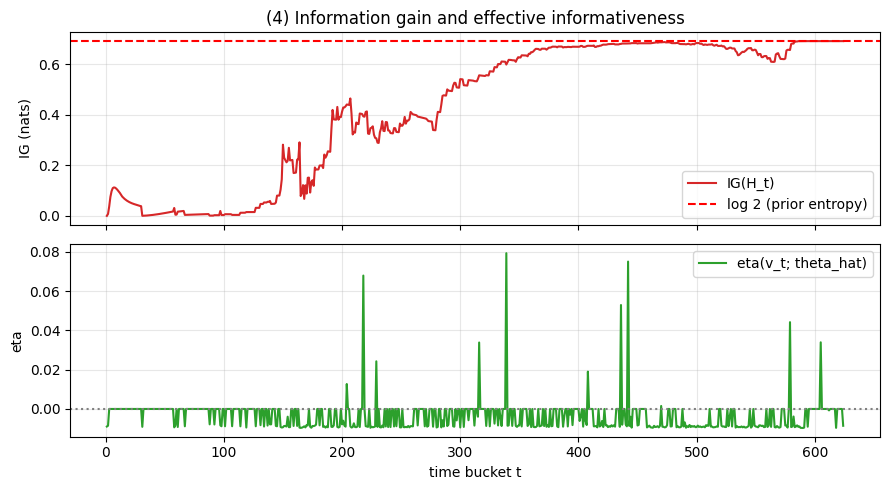

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
axes[0].plot(ts, ig, color='C3', label='IG(H_t)')
axes[0].axhline(np.log(2), linestyle='--', color='red', label='log 2 (prior entropy)')
axes[0].set_ylabel('IG (nats)')
axes[0].set_title('(4) Information gain and effective informativeness')
axes[0].legend()

axes[1].plot(ts, eta, color='C2', label='eta(v_t; theta_hat)')
axes[1].axhline(0.0, linestyle=':', color='gray')
axes[1].set_xlabel('time bucket t')
axes[1].set_ylabel('eta')
axes[1].legend()
plt.tight_layout()
plt.show()